In [80]:
import json
import logging
from pathlib import Path

with open("settings_eda.json", "r") as f:settings = json.load(f)
log_enabled = settings["logging"]["enabled"]
log_level0 = settings["logging"]["level"]
log_file = settings["logging"]["file"]

log_level = getattr(logging, log_level0)
logger = logging.getLogger("project_logger")
logger.handlers.clear()
if log_enabled:
    Path(log_file).parent.mkdir(parents=True, exist_ok=True)
    logger.setLevel(log_level)
    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(log_level)
    formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    logger.info("Логирование включено")
else:
    logger.disabled = True
logger.info("Привет")

INFO:project_logger:Логирование включено
INFO:project_logger:Привет


# Первый датасет

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('posts1.csv')
duplicates_count = df1.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count}")

print("\nКоличество пустых ячеек по столбцам:")
print(df1.isnull().sum())
df1['tagline'] = df1['tagline'].fillna('')

print("\nРазмер таблицы:", df1.shape)
logger.info("Датасет 1 загружен для аналитики")

INFO:project_logger:Датасет 1 загружен для аналитики


Количество полных дубликатов: 0

Количество пустых ячеек по столбцам:
post_id              0
post_name            0
slug                 0
tagline              0
votes_count          0
comments_count       0
reviews_count        0
reviews_rating       0
created_at           0
featured_at        665
post_url             0
website              0
author_username      0
dtype: int64

Размер таблицы: (762, 13)


Ниже сделаем корр матрицу некоторых признаков:

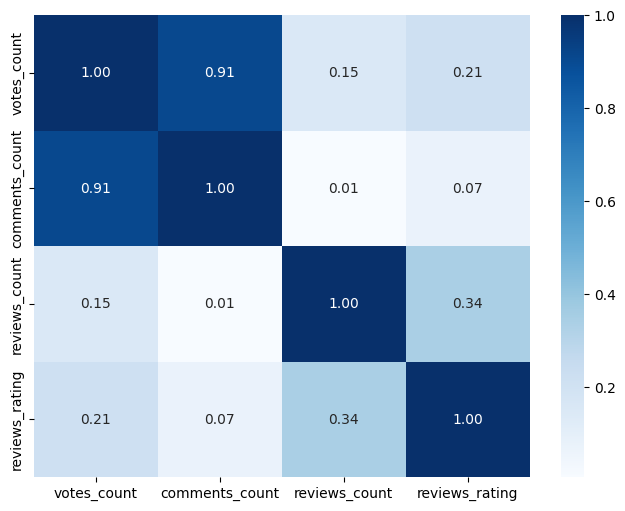

INFO:project_logger:Корр матрица по датасету 1 построена успешно


In [82]:
columns_for_corr = ['votes_count', 'comments_count', 'reviews_count', 'reviews_rating']
df_numeric = df1[columns_for_corr]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f")

plt.show()
logger.info("Корр матрица по датасету 1 построена успешно")

Далее смотрим сразу три измерения: как связаны комментарии и голоса, и какой буст дает плашка "Featured" (попадание на главную):

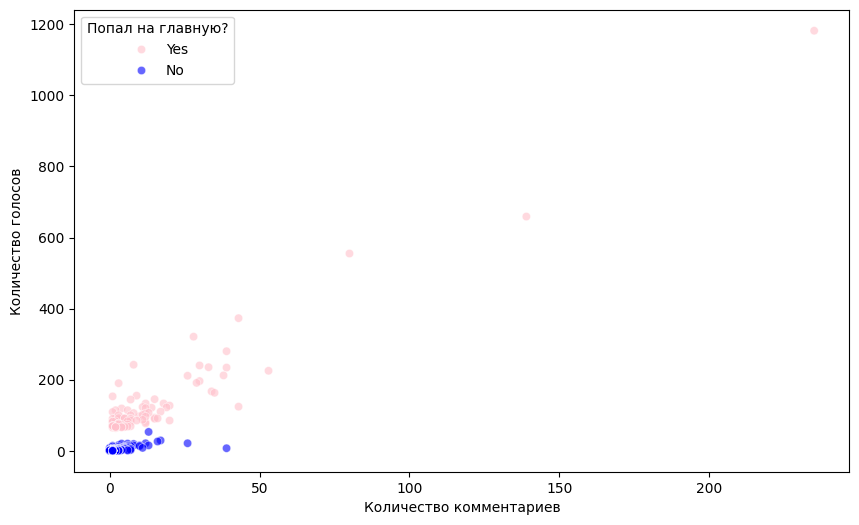

INFO:project_logger:График 2 для датасета 1 статус: success


In [83]:
# новый параметр: попал ли на главную? Если featured_at заполнена, то yes, иначе - no
df1['is_featured'] = df1['featured_at'].notna().map({True: 'Yes', False: 'No'})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df1,
    x='comments_count',
    y='votes_count',
    hue='is_featured',
    palette={'Yes': 'pink', 'No': 'blue'},
    alpha=0.6
)

plt.xlabel('Количество комментариев')
plt.ylabel('Количество голосов')
plt.legend(title='Попал на главную?')

plt.show()
logger.info("График 2 для датасета 1 статус: success")

Проверим простое правило: влияет ли длина текста (слогана) на количество голосов.

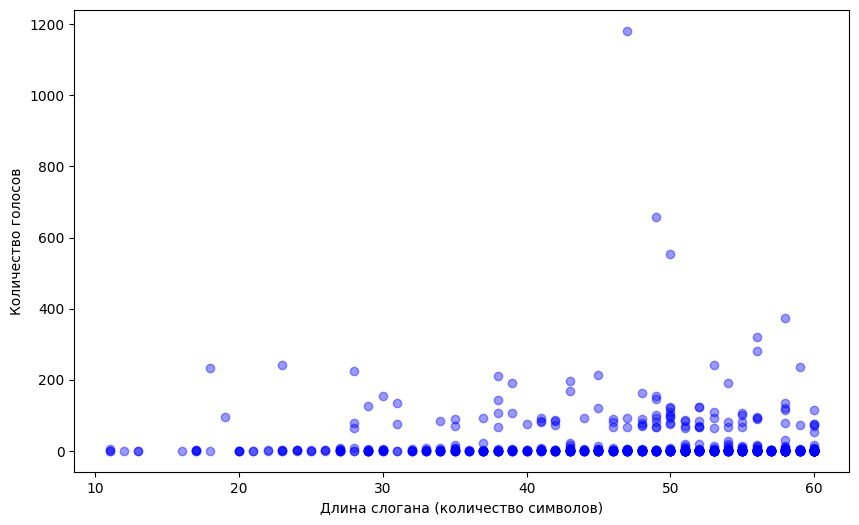

INFO:project_logger:График 3 для датасета 1 статус: success


In [84]:
# еще один новый параметр - длина текста (количество символов)
df1['tagline_length'] = df1['tagline'].astype(str).str.len()

plt.figure(figsize=(10, 6))
plt.scatter(df1['tagline_length'], df1['votes_count'], color='blue', alpha=0.4)

plt.xlabel('Длина слогана (количество символов)')
plt.ylabel('Количество голосов')
plt.show()
logger.info("График 3 для датасета 1 статус: success")

Однако это может быть ввиду того, что так делает большинство. Поэтому стоит посмотреть более масштабно: а какая длина слогана наиболее распространена?

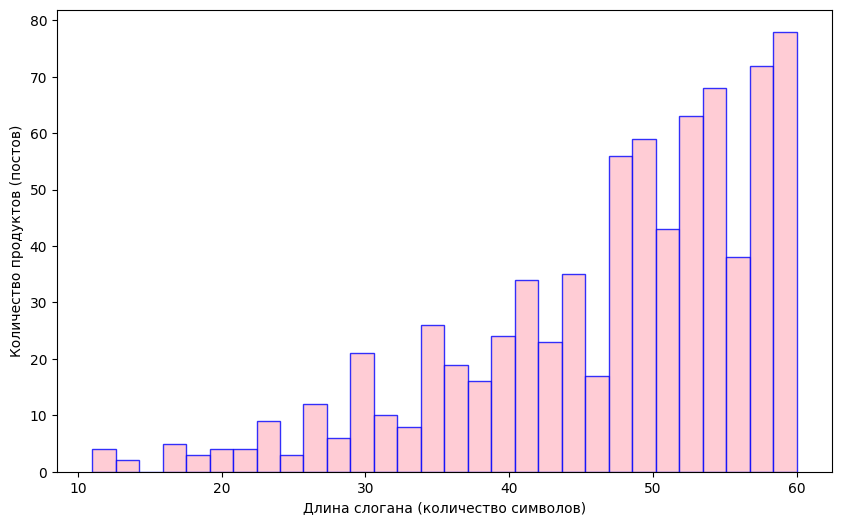

INFO:project_logger:График 3_1 для датасета 1 статус: success


In [86]:
df1['tagline_char_length'] = df1['tagline'].astype(str).str.len()

plt.figure(figsize=(10, 6))

plt.hist(df1['tagline_char_length'], bins=30, color='pink', edgecolor='blue', alpha=0.8)

plt.xlabel('Длина слогана (количество символов)')
plt.ylabel('Количество продуктов (постов)')

plt.show()
logger.info("График 3_1 для датасета 1 статус: success")

Мы получили логичный резудьтат. Однако разное кол-во слов содержит разное кол-во значений, поэтому ниже посмотрели такое же распределение, только не по символам, а по словам

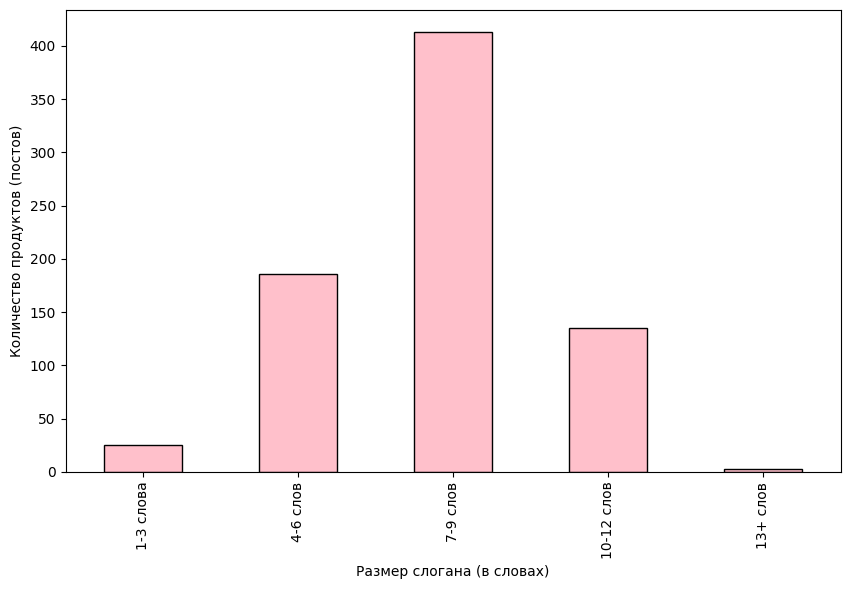

INFO:project_logger:График 3_2 для датасета 1 статус: success


In [87]:
df1['word_count'] = df1['tagline'].apply(lambda x: len(str(x).split()))

bins = [0, 3, 6, 9, 12, 100]
labels = ['1-3 слова', '4-6 слов', '7-9 слов', '10-12 слов', '13+ слов'] # Названия групп

df1['word_count_group'] = pd.cut(df1['word_count'], bins=bins, labels=labels)

slogan_counts = df1['word_count_group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

slogan_counts.plot(kind='bar', color="pink", edgecolor='black')

plt.xlabel('Размер слогана (в словах)')
plt.ylabel('Количество продуктов (постов)')

plt.show()
logger.info("График 3_2 для датасета 1 статус: success")

# Второй датасет

In [88]:
df2 = pd.read_csv('topics1.csv')

duplicates_count2 = df2.duplicated().sum()
print(f"Количество полных дубликатов: {duplicates_count2}")

print("\nКоличество пустых ячеек по столбцам:")
print(df2.isnull().sum())

print("\nРазмер таблицы:", df2.shape)
logger.info("Датасет 2 загружен для аналитики статус: success")

INFO:project_logger:Датасет 2 загружен для аналитики статус: success


Количество полных дубликатов: 0

Количество пустых ячеек по столбцам:
topic_id           0
topic_name         0
topic_slug         0
followers_count    0
dtype: int64

Размер таблицы: (425, 4)


Мы просто отсортируем темы по числу подписчиков и выведем на экран 15 самых крупных

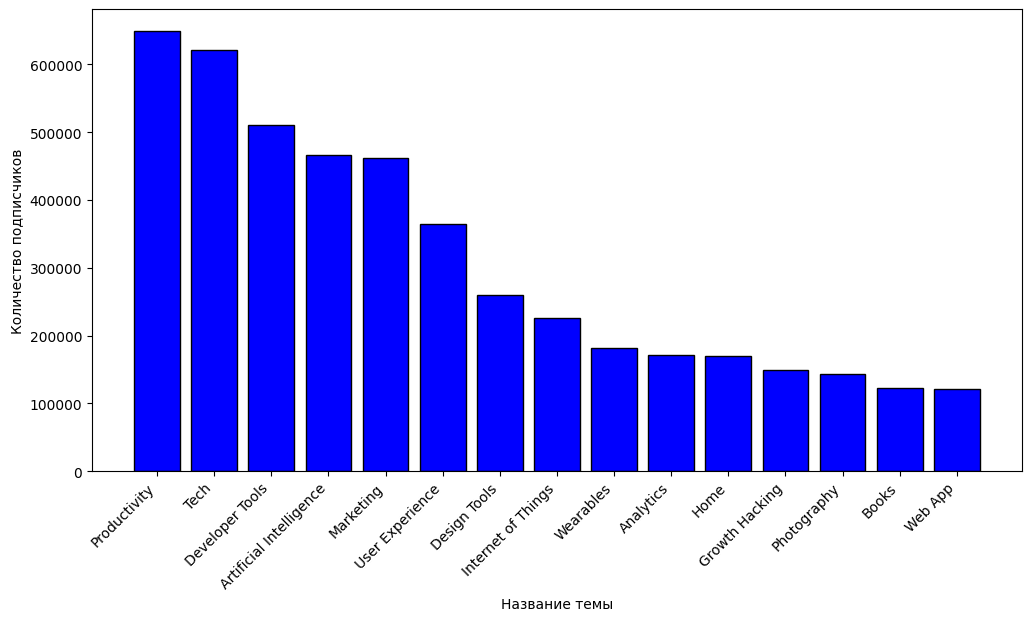

INFO:project_logger:График 1 для датасета 2 статус: success


In [89]:
# сортируем таблицу по подписчикам по убыванию и берем первые 15 строк
top_15_topics = df2.sort_values(by='followers_count', ascending=False).head(15)

plt.figure(figsize=(12, 6))

plt.bar(top_15_topics['topic_name'], top_15_topics['followers_count'], color="blue", edgecolor='black')

plt.xlabel('Название темы')
plt.ylabel('Количество подписчиков')
plt.xticks(rotation=45, ha='right')

plt.show()
logger.info("График 1 для датасета 2 статус: success")

Далее мы посмотрим на распределение аудитории. Есть ли на рынке "темы-монополисты", которые аномально огромны по сравнению с остальными?

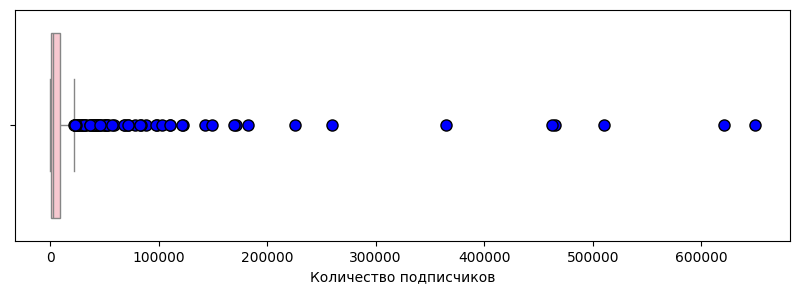

INFO:project_logger:График 2 для датасета 2 статус: success


In [90]:
plt.figure(figsize=(10, 3))

# розовый ящик - это основная масса тем, а синие точки - это выбросы (супер-темы)
sns.boxplot(
    x=df2['followers_count'],
    color='pink',
    flierprops={'markerfacecolor':'blue', 'markeredgecolor':'black', 'markersize': 8}
)

plt.xlabel('Количество подписчиков')

plt.show()
logger.info("График 2 для датасета 2 статус: success")

Проверим гипотезу: правда ли, что всего ТОП-10 тем забирают себе почти всех подписчиков платформы?

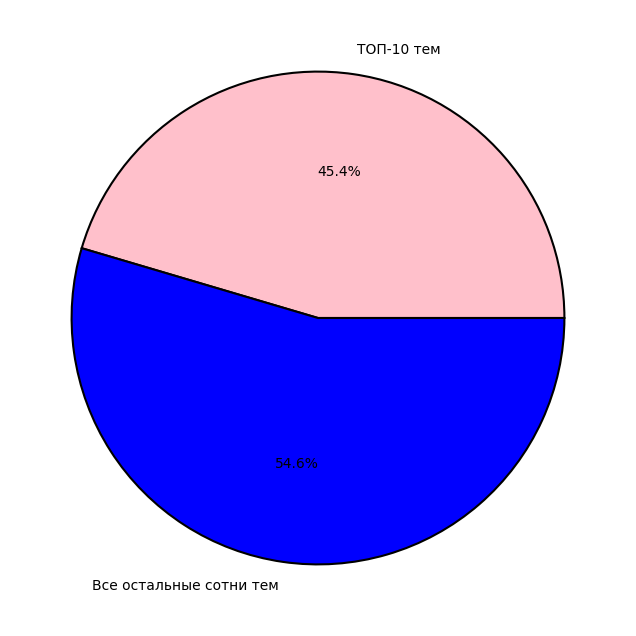

INFO:project_logger:График 3 для датасета 2 статус: success


In [92]:
# общее количество подписчиков у Топ-10 самых популярных тем
top_10_sum = df2.sort_values(by='followers_count', ascending=False).head(10)['followers_count'].sum()

# общее количество подписчиков у всех остальных тем (начиная с 11-й)
other_sum = df2.sort_values(by='followers_count', ascending=False).iloc[10:]['followers_count'].sum()

sizes = [top_10_sum, other_sum]
labels = ['ТОП-10 тем', 'Все остальные сотни тем']
colors = ['pink', 'blue']

plt.figure(figsize=(8, 8))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.5} # черная обводка
)


plt.show()
logger.info("График 3 для датасета 2 статус: success")

# Третий датасет

In [93]:
df3 = pd.read_csv('collections1.csv')

# удаляем мусорный столбец tagline
df3 = df3.drop(columns=['tagline'])

# заполняем 107 пустых описаний пустой строкой, чтобы они не ломали код
df3['description'] = df3['description'].fillna('')

print("Количество пустых ячеек теперь:")
print(df3.isnull().sum())
print("\nРазмер таблицы:", df3.shape)
logger.info("Датасет 3 загружен для аналитики статус: success")

INFO:project_logger:Датасет 3 загружен для аналитики статус: success


Количество пустых ячеек теперь:
collection_id      0
collection_name    0
description        0
followers_count    0
collection_url     0
dtype: int64

Размер таблицы: (1007, 5)


Посмотрим на самых крупных игроков на рынке — коллекции с максимальным числом подписчиков

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128241 (\N{MOBILE PHONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128421 (\N{DESKTOP COMPUTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


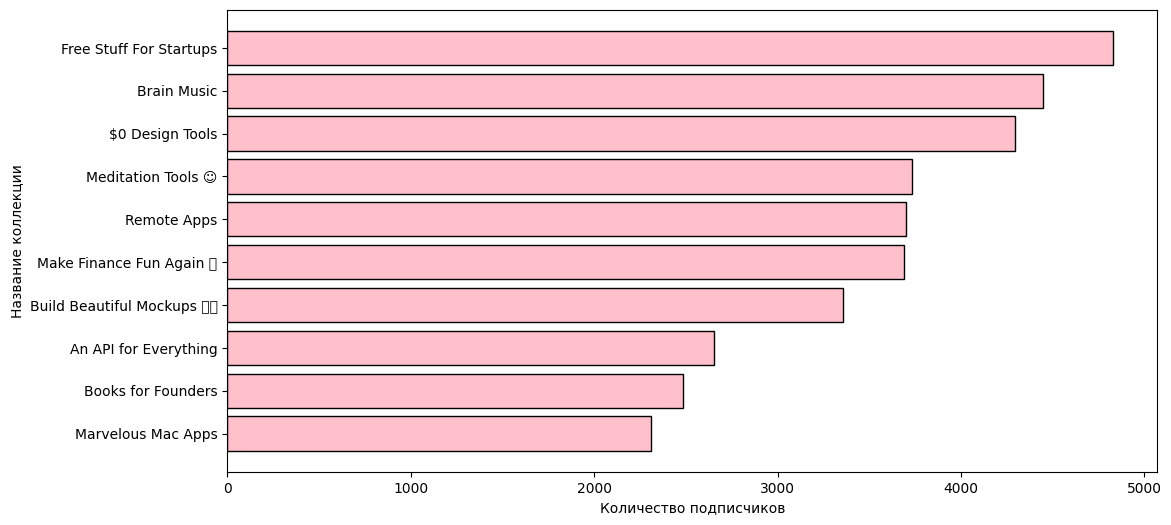

INFO:project_logger:График 1 для датасета 3 статус: success


In [94]:
top_10_cols = df3.sort_values(by='followers_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))

plt.barh(top_10_cols['collection_name'][::-1], top_10_cols['followers_count'][::-1], color='pink', edgecolor='black')

plt.xlabel('Количество подписчиков')
plt.ylabel('Название коллекции')

plt.show()
logger.info("График 1 для датасета 3 статус: success")

Семантика успешных подборок: делаем поиск слов супер-просто (разобьем весь текст на слова, выкинем мусор (предлоги типа and, the, for) и посчитаем самые популярные)

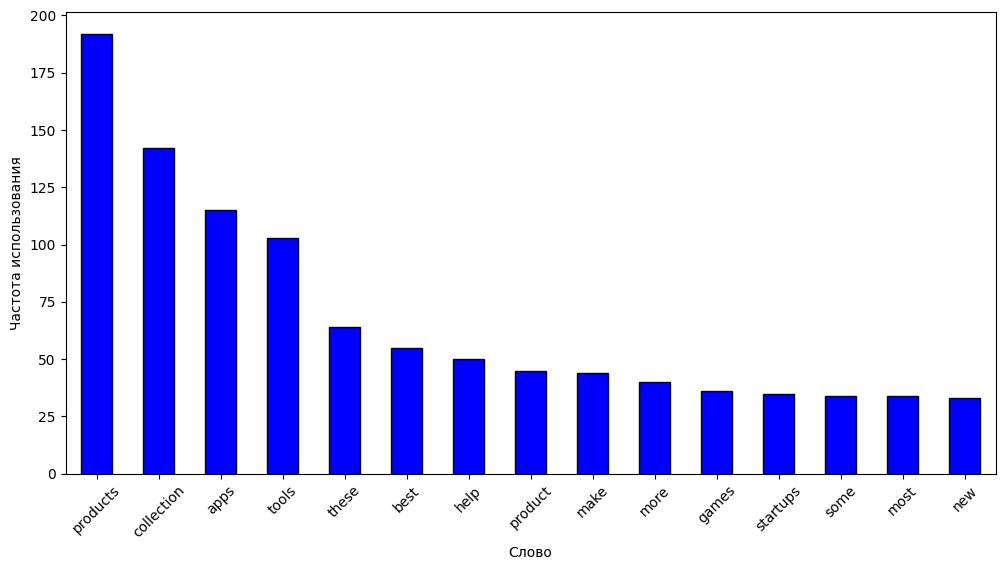

INFO:project_logger:График 2 для датасета 3 статус: success


In [95]:
# склеиваем все описания в один огромный текст и переводим в нижний регистр
all_text = " ".join(df3['description'].tolist()).lower()

# скипаем базовые знаки препинания (просто меняем их на пробелы)
for char in [',', '.', '!', '?', '-', '"', '(', ')', '/']:
    all_text = all_text.replace(char, ' ')

words = all_text.split()

stop_words = ['and', 'to', 'for', 'the', 'a', 'of', 'in', 'with', 'is', 'on', 'your', 'that', 'from', 'by', 'are', 'you', 'it', 'all', 'this']

# оставляем только слова, которых нет в списке "мусора", и которые длиннее 2 букв
meaningful_words = [word for word in words if word not in stop_words and len(word) > 2]

# топ-15 самых частых слов
word_counts = pd.Series(meaningful_words).value_counts().head(15)

plt.figure(figsize=(12, 6))
word_counts.plot(kind='bar', color=['blue'], edgecolor='black')

plt.xlabel('Слово')
plt.ylabel('Частота использования')
plt.xticks(rotation=45)

plt.show()
logger.info("График 2 для датасета 3 статус: success")

Посмотрим, сколько вообще подписчиков собирает среднестатистическая коллекция.  Поскольку на платформе может быть пара коллекций с миллионами подписок (они сломают график), мы хитро отрежем топ-5% аномалий и посмотрим на типичные 95% рынка.

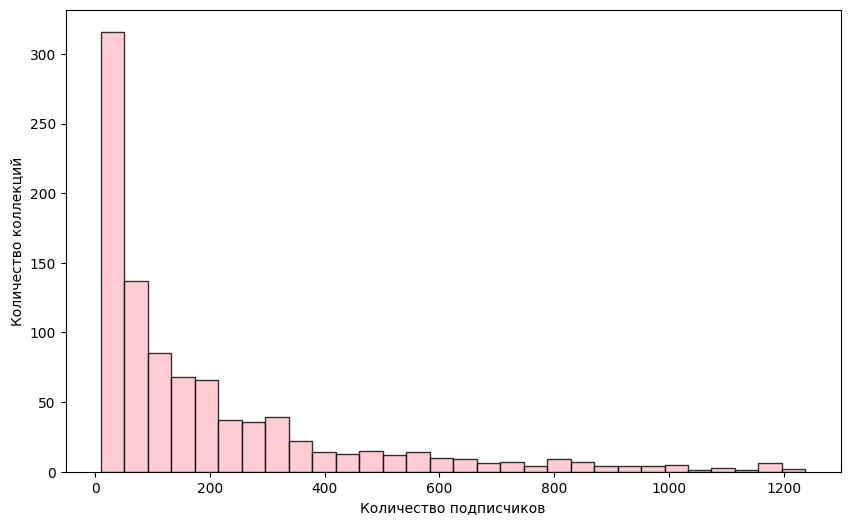

INFO:project_logger:График 3 для датасета 3 статус: success


In [100]:
plt.figure(figsize=(10, 6))

limit = df3['followers_count'].quantile(0.95)

normal_collections = df3[df3['followers_count'] <= limit]

plt.hist(normal_collections['followers_count'], bins=30, color='pink', edgecolor='black', alpha=0.8)


plt.xlabel('Количество подписчиков')
plt.ylabel('Количество коллекций')

plt.show()
logger.info("График 3 для датасета 3 статус: success")

# Пятый датасет

In [109]:
df5 = pd.read_csv('comment1.csv')

if 'parent_id' in df5.columns:
    df5 = df5.drop(columns=['parent_id'])

# вытаскиваем название продукта из ссылки (comment_url)
df5['product_slug'] = df5['comment_url'].apply(
    lambda x: str(x).split('/products/')[1].split('?')[0] if '/products/' in str(x) else 'unknown'
)

df5['created_at'] = pd.to_datetime(df5['created_at'])

print("Данные готовы! Уникальных продуктов обсуждается:", df5['product_slug'].nunique())
print("\nРазмер таблицы:", df5.shape)
logger.info("Датасет 5 загружен для аналитики статус: success")

INFO:project_logger:Датасет 5 загружен для аналитики статус: success


Данные готовы! Уникальных продуктов обсуждается: 11

Размер таблицы: (40, 11)


Посмотрим, какие продукты из нашей выборки собрали больше всего комментариев

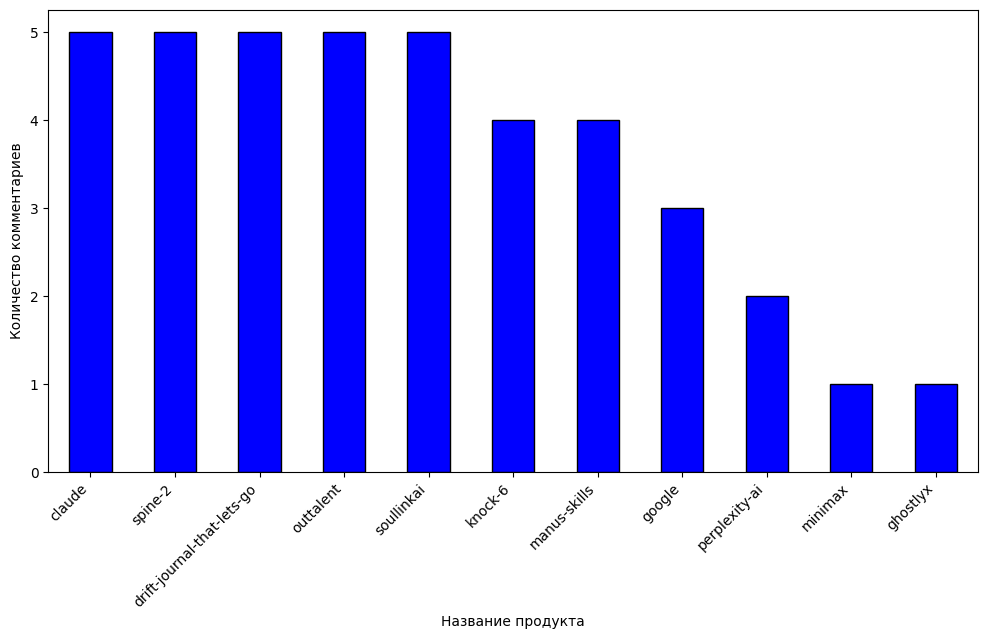

INFO:project_logger:График 1 для датасета 5 статус: success


In [112]:
top_discussed = df5['product_slug'].value_counts()

plt.figure(figsize=(12, 6))

top_discussed.plot(kind='bar', color='blue', edgecolor='black')

plt.xlabel('Название продукта')
plt.ylabel('Количество комментариев')

plt.xticks(rotation=45, ha='right')
plt.show()
logger.info("График 1 для датасета 5 статус: success")

Существует гипотеза, что короткие комменты ("Awesome!", "Great job!") никто не лайкает, а длинные развернутые отзывы собирают много плюсов (голосов), сейчас это и посмотрим

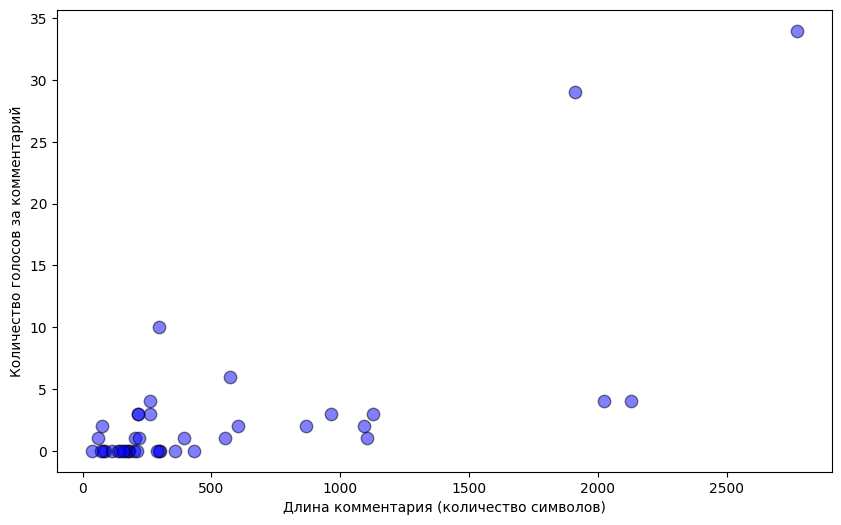

INFO:project_logger:График 2 для датасета 5 статус: success


In [116]:
df5['comment_length'] = df5['body'].astype(str).str.len()

plt.figure(figsize=(10, 6))

plt.scatter(df5['comment_length'], df5['votes_count'], color='blue', edgecolor='black', alpha=0.5, s=80)

plt.xlabel('Длина комментария (количество символов)')
plt.ylabel('Количество голосов за комментарий')

plt.show()
logger.info("График 2 для датасета 5 статус: success")

Чтобы комьюнити-менеджер стартапа не сидел на сайте сутками, мы найдем "золотые часы", когда пользователи пишут комментарии чаще всего.

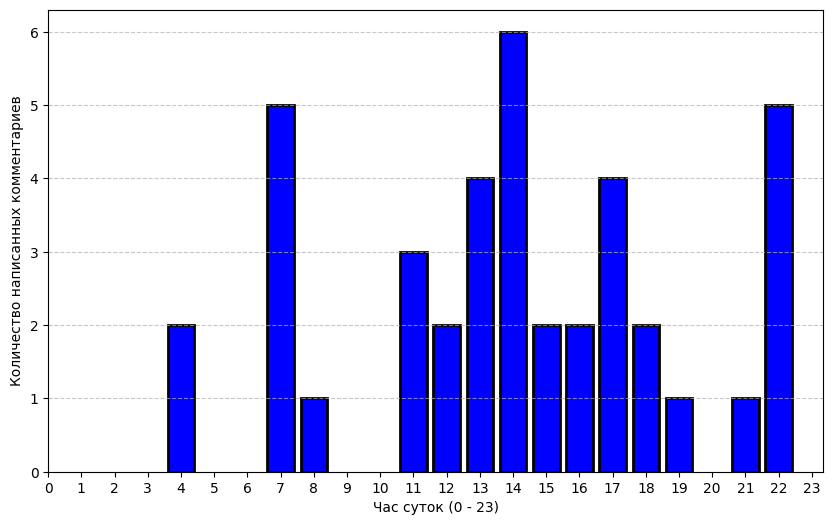

INFO:project_logger:График 3 для датасета 5 статус: success


In [123]:
df5['hour'] = df5['created_at'].dt.hour

comments_by_hour = df5['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(comments_by_hour.index, comments_by_hour.values, color='blue', edgecolor='black', linewidth=2)

plt.xlabel('Час суток (0 - 23)')
plt.ylabel('Количество написанных комментариев')
plt.xticks(range(0, 24))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
logger.info("График 3 для датасета 5 статус: success")

# Шестой датасет

In [144]:
df6 = pd.read_csv('planeta_raw.csv')

df6 = df6[df6['error'] != 'gate'].copy()

duplicates_count = df6.duplicated().sum()
if duplicates_count > 0:
    df6 = df6.drop_duplicates()

df6['description'] = df6['description'].fillna('')

print(f"Количество полных дубликатов: {duplicates_count}")

print("\nКоличество пустых ячеек по столбцам (первые 10):")
print(df6.isnull().sum().head(10))

print("\nРазмер таблицы:", df6.shape)
logger.info("Датасет 6 загружен для аналитики статус: success")

INFO:project_logger:Датасет 6 загружен для аналитики статус: success


Количество полных дубликатов: 0

Количество пустых ячеек по столбцам (первые 10):
project_url             0
title                   0
title_length            0
description             0
category                5
author                114
region                245
goal_rub                0
pledged_rub             0
funding_percentage      0
dtype: int64

Размер таблицы: (1030, 31)


Проверяем, какие ниши собирают больше всего средств на этой платформе

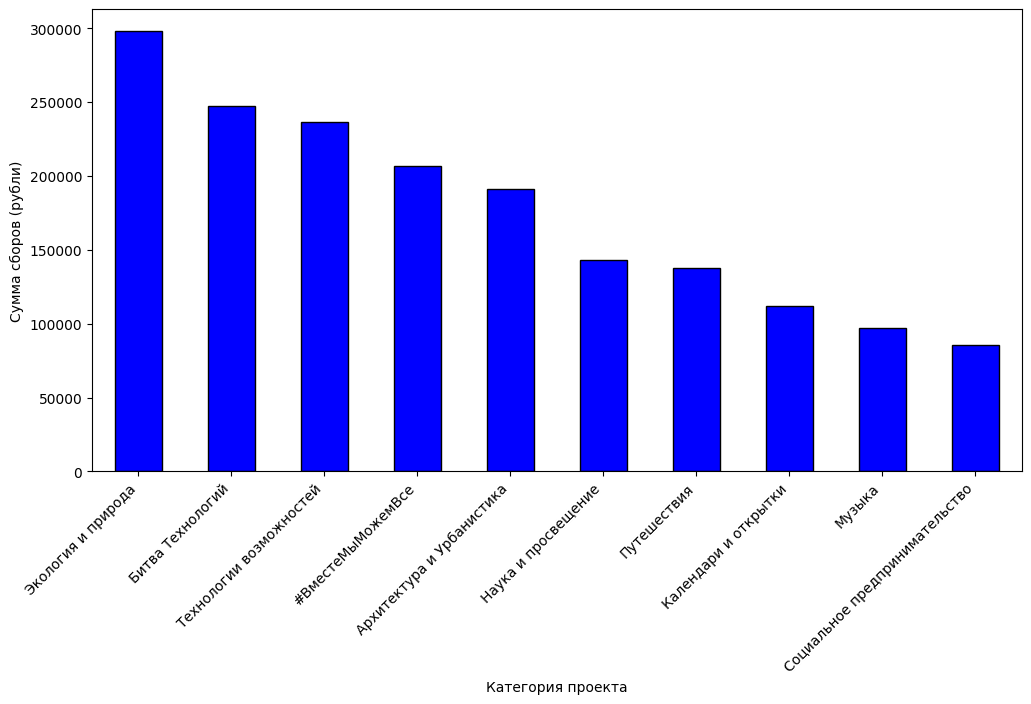

INFO:project_logger:График 1 для датасета 6 статус: success


In [146]:
category_pledged = df6.groupby('category')['pledged_rub'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))

category_pledged.plot(kind='bar', color='blue', edgecolor='black')

plt.xlabel('Категория проекта')
plt.ylabel('Сумма сборов (рубли)')

plt.xticks(rotation=45, ha='right')
plt.show()
logger.info("График 1 для датасета 6 статус: success")

Мы нашли еще параметр has_video, тогда надо проверить: действительно ли наличие видеопрезентации помогает собрать больший процент от заявленной финансовой цели

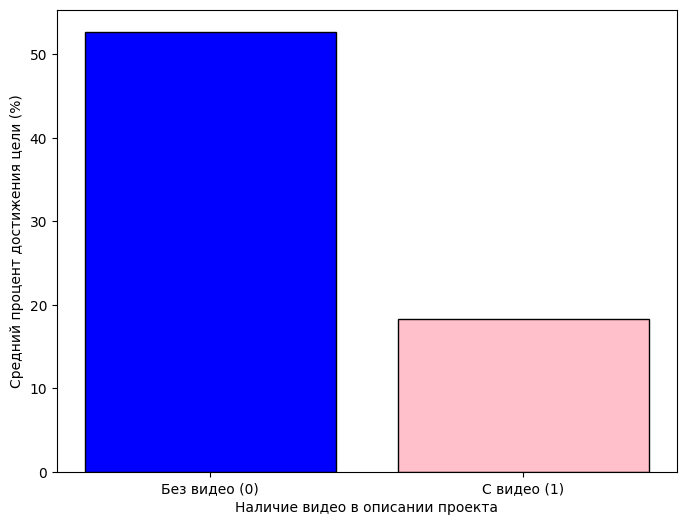

INFO:project_logger:График 2 для датасета 6 статус: success


In [148]:
video_impact = df6.groupby('has_video')['funding_percentage'].mean()

plt.figure(figsize=(8, 6))

plt.bar(['Без видео (0)', 'С видео (1)'], video_impact.values, color=['blue', 'pink'], edgecolor='black')

plt.xlabel('Наличие видео в описании проекта')
plt.ylabel('Средний процент достижения цели (%)')

plt.show()
logger.info("График 2 для датасета 6 статус: success")

Кому инвестроры доверят инвестиции охотнее: новичку с первой кампанией или опытному автору, который уже запускал проекты?

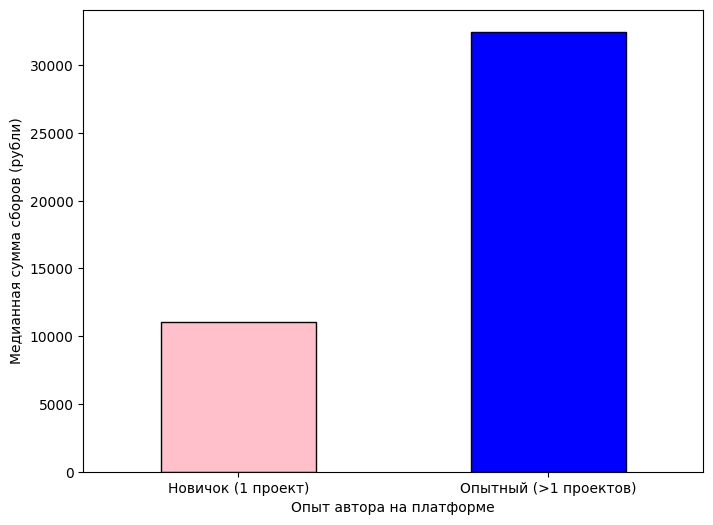

INFO:project_logger:График 3 для датасета 6 статус: success


In [150]:
df6['is_experienced'] = df6['created_projects'].apply(
    lambda x: 'Новичок (1 проект)' if x <= 1 else 'Опытный (>1 проектов)'
)

experience_pledged = df6.groupby('is_experienced')['pledged_rub'].median()

plt.figure(figsize=(8, 6))

experience_pledged.plot(kind='bar', color=['pink', 'blue'], edgecolor='black')

plt.xlabel('Опыт автора на платформе')
plt.ylabel('Медианная сумма сборов (рубли)')

plt.xticks(rotation=0)
plt.show()
logger.info("График 3 для датасета 6 статус: success")

Возможно такая статистика из-за сильного перевеса кол-ва новичков, надо проверить

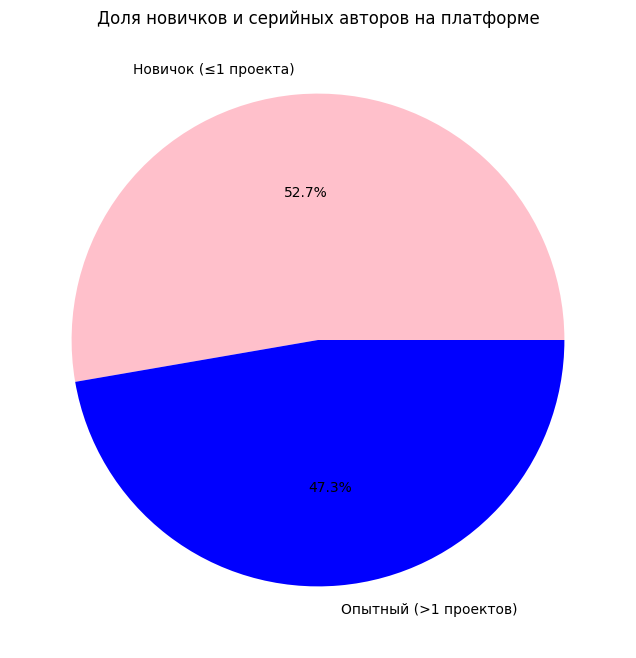

INFO:project_logger:График 3_1 для датасета 6 статус: success


In [152]:
df6['is_experienced'] = df6['created_projects'].apply(
    lambda x: 'Новичок (≤1 проекта)' if x <= 1 else 'Опытный (>1 проектов)'
)

experience_counts = df6['is_experienced'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    experience_counts.values,
    labels=experience_counts.index,
    colors=['pink', 'blue'],
    autopct='%1.1f%%' # показывать проценты
)

plt.title('Доля новичков и серийных авторов на платформе')

plt.show()
logger.info("График 3_1 для датасета 6 статус: success")